In [6]:
# GPU Environment Setup
import os
import sys

# Set environment variables for GPU and threading
os.environ['SLURM_CPU_BIND'] = 'cores'
os.environ['NUMEXPR_MAX_THREADS'] = '128'
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
os.environ['TF_NUM_INTEROP_THREADS'] = '8'
os.environ['TF_NUM_INTRAOP_THREADS'] = '16'
os.environ['OMP_NUM_THREADS'] = '16'
os.environ['PYTHONUNBUFFERED'] = '1'

print("GPU environment configured!")
print(f"CUDA_VISIBLE_DEVICES: {os.environ.get('CUDA_VISIBLE_DEVICES', 'Not set')}")

# Verify GPU access
try:
    !nvidia-smi -L
except:
    print("Warning: nvidia-smi not available")

GPU environment configured!
CUDA_VISIBLE_DEVICES: 0
NVIDIA-SMI has failed because it couldn't communicate with the NVIDIA driver. Make sure that the latest NVIDIA driver is installed and running.



In [7]:
# ============================================================================
# Event Display for HGTD Vertex Timing Analysis
# ============================================================================

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
from matplotlib.backends.backend_pdf import PdfPages
from pathlib import Path

# ============================================================================
# Configuration
# ============================================================================

DATA_PATH = '../Vertex_timing_HGTD_w_LAr/'
OUTPUT_PATH = './event_displays/'

# Create output directory if it doesn't exist
Path(OUTPUT_PATH).mkdir(parents=True, exist_ok=True)

print("✅ Libraries imported and configuration set")
print(f"   DATA_PATH: {DATA_PATH}")
print(f"   OUTPUT_PATH: {OUTPUT_PATH}")

✅ Libraries imported and configuration set
   DATA_PATH: ../Vertex_timing_HGTD_w_LAr/
   OUTPUT_PATH: ./event_displays/


In [17]:
# ============================================================================
# Data Loading Functions
# ============================================================================

def find_event_in_file(file_num, event_number):
    """
    Find event index in HDF5 file by eventNumber
    
    Args:
        file_num: File index (0-49)
        event_number: Event number from HDF5
    
    Returns:
        event_idx or None if not found
    """
    file_path = f'{DATA_PATH}output_{file_num:03d}.h5'
    
    with h5py.File(file_path, 'r') as f:
        event_numbers = f['HSvertex']['eventNumber'][:]
        matches = np.where(event_numbers == event_number)[0]
        
        if len(matches) == 0:
            return None
        
        return matches[0]

def find_event_globally(event_number, max_files=50):
    """
    Find event across all files by eventNumber (if globally unique)
    
    Args:
        event_number: Event number to find
        max_files: Maximum number of files to search
    
    Returns:
        (file_num, event_idx) or (None, None) if not found
    """
    for file_num in range(max_files):
        file_path = f'{DATA_PATH}output_{file_num:03d}.h5'
        if not Path(file_path).exists():
            continue
            
        event_idx = find_event_in_file(file_num, event_number)
        if event_idx is not None:
            return file_num, event_idx
    
    return None, None

def load_event_from_hdf5(file_num, event_idx):
    """
    Load a single event from HDF5 file using array index
    
    Args:
        file_num: File index (0-49)
        event_idx: Event index within the file (0-5099)
    
    Returns:
        Dictionary containing event data
    """
    file_path = f'{DATA_PATH}output_{file_num:03d}.h5'
    
    with h5py.File(file_path, 'r') as f:
        event_data = {
            'HSvertex': f['HSvertex'][event_idx],
            'cells': f['cells'][event_idx],
            'jets': f['jets'][event_idx],
            'tracks': f['tracks'][event_idx],
            'tracks_HGTD': f['tracks_HGTD'][event_idx],
            'eventNumber': f['HSvertex'][event_idx]['eventNumber'],
            'file_num': file_num,
            'event_idx': event_idx
        }
    
    return event_data

def load_event_from_predictions_index(predictions_data, idx):
    """
    Load event using index from predictions.npz
    
    Args:
        predictions_data: Loaded npz file
        idx: Index in the predictions array
    
    Returns:
        Dictionary containing event data
    """
    file_num = int(predictions_data['file_indices'][idx])
    event_number = int(predictions_data['event_numbers'][idx])
    
    # Find event index in file
    event_idx = find_event_in_file(file_num, event_number)
    
    if event_idx is None:
        raise ValueError(f"Event {event_number} not found in file {file_num}")
    
    return load_event_from_hdf5(file_num, event_idx)

print("✅ Data loading functions defined")

# ============================================================================
# Event Processing Functions
# ============================================================================

def process_tracks_hdf5(event_data):
    """Process track information from HDF5 event data"""
    tracks = event_data['tracks_HGTD']
    hs_vertex = event_data['HSvertex']
    
    # Filter valid tracks
    valid_mask = tracks['valid']
    
    track_info = []
    for i, track in enumerate(tracks[valid_mask]):
        # Calculate geometric properties
        eta = track['Track_eta']
        phi = track['Track_phi']
        pt = track['Track_pt']
        z0 = track['Track_z0']
        
        # Check if in HGTD acceptance
        in_hgtd = abs(eta) > 2.38 and abs(eta) < 4.0
        if not in_hgtd:
            continue
        
        # Check track quality
        has_valid_time = track['Track_hasValidTime'] == 1
        is_good_quality = track['Track_quality'] == 1
        is_from_hs = track['Track_isGoodFromHS'] == 1
        
        if not (has_valid_time and pt > 1.0):
            continue
        
        # Calculate position for R-Z display
        pz = pt * np.sinh(eta)
        signX = np.sign(eta) if eta != 0 else 1
        signY = np.sign(np.sin(phi)) if np.sin(phi) != 0 else 1
        theta = np.arctan(pt / abs(pz))
        x = (pt / 2) * np.cos(theta) * signX
        y = (pt / 2) * np.sin(theta) * signY
        
        track_info.append({
            'z0': z0,
            'x': x,
            'y': y,
            'stat': is_from_hs,
            'idx': i,
            'pt': pt,
            'time': track['Track_time'],
            'time_res': track['Track_timeRes'],
            'var_z0': track['Track_var_z0']
        })
    
    return track_info

def process_jets_hdf5(event_data):
    """Process jet information from HDF5 event data"""
    jets = event_data['jets']
    hs_vertex_z = event_data['HSvertex']['HSvertex_reco_z']
    
    # Filter valid jets
    valid_mask = jets['valid']
    
    jet_info = []
    for jet in jets[valid_mask]:
        jet_pt = jet['AntiKt4EMTopoJets_pt']
        
        if jet_pt < 30.0:
            continue
        
        jet_eta = jet['AntiKt4EMTopoJets_eta']
        jet_phi = jet['AntiKt4EMTopoJets_phi']
        is_selected = jet['AntiKt4EMTopoJets_selected']
        
        # Calculate position for R-Z display
        pz = jet_pt * np.sinh(jet_eta)
        signX = np.sign(jet_eta) if jet_eta != 0 else 1
        signY = np.sign(np.sin(jet_phi)) if np.sin(jet_phi) != 0 else 1
        theta = np.arctan(jet_pt / abs(pz))
        x_jet = (jet_pt / 40) * np.cos(theta) * signX
        y_jet = (jet_pt / 40) * np.sin(theta) * signY
        
        jet_info.append({
            'pt': jet_pt,
            'eta': jet_eta,
            'phi': jet_phi,
            'isHS': is_selected,
            'x': x_jet,
            'y': y_jet
        })
    
    return jet_info

def get_vertex_info(event_data):
    """Extract vertex information"""
    hs_vertex = event_data['HSvertex']
    
    vertex_info = {
        'truth_x': hs_vertex['HSvertex_x'],
        'truth_y': hs_vertex['HSvertex_y'],
        'truth_z': hs_vertex['HSvertex_z'],
        'truth_t': hs_vertex['HSvertex_time'],
        'reco_x': hs_vertex['HSvertex_reco_x'],
        'reco_y': hs_vertex['HSvertex_reco_y'],
        'reco_z': hs_vertex['HSvertex_reco_z'],
        'event_number': hs_vertex['eventNumber']
    }
    
    return vertex_info

print("✅ Event processing functions defined")

✅ Data loading functions defined
✅ Event processing functions defined


In [18]:
# ============================================================================
# Plotting Functions
# ============================================================================

def draw_eta_reference_lines(ax, z_pos, eta_ref=2.4, line_length=50):
    """Draw lines corresponding to |eta| = eta_ref"""
    theta_ref = 2 * np.arctan(np.exp(-abs(eta_ref)))
    x_ref = line_length * np.cos(theta_ref)
    y_ref = line_length * np.sin(theta_ref)
    props = {'linestyle': 'dotted', 'color': 'lightgrey'}
    for dx in [x_ref, -x_ref]:
        for dy in [y_ref, -y_ref]:
            ax.plot([z_pos, z_pos + dx], [0, dy], **props)

def plot_rz_display(ax, track_info, jet_info, vertex_info, event_num, file_num):
    """Plot Event Display in R-Z Plane"""
    reco_z = vertex_info['reco_z']
    truth_z = vertex_info['truth_z']
    
    # Plot tracks
    for track in track_info:
        color = 'blue' if track['stat'] == 1 else 'red'
        ax.plot([track['z0'], track['z0'] + track['x']], [0, track['y']],
               color=color, linestyle='solid', alpha=0.7)
    
    # Plot jets
    for jet_i, jet in enumerate(jet_info):
        jet_color = 'green' if jet['isHS'] >= 1 else 'grey'
        x_off1 = jet['x'] - 0.15 * jet['y']
        y_off1 = jet['y'] + 0.15 * jet['x']
        x_off2 = jet['x'] + 0.15 * jet['y']
        y_off2 = jet['y'] - 0.15 * jet['x']
        ax.fill([reco_z, reco_z + x_off1, reco_z + x_off2], 
               [0, y_off1, y_off2], color=jet_color, alpha=0.5)
        
        txt_color = 'green' if jet['isHS'] >= 1 else 'black'
        # FIX: Use single $ for math mode, not double $$
        ax.text(reco_z - 6.8, 0.9 - (1.2 + jet_i * 0.1),
               f"Jet {jet_i+1}: $p_T$={jet['pt']:.0f} GeV, $\\eta$={jet['eta']:.1f}",
               weight='bold', fontsize=12, color=txt_color)
    
    # Reference lines
    draw_eta_reference_lines(ax, reco_z, 2.4)
    
    # Vertices
    ax.scatter([reco_z], [0], marker='o', s=100, color='blue', zorder=10)
    ax.scatter([truth_z], [-0.75], marker='|', s=100, color='blue', zorder=10)
    
    # Axis settings
    ax.set_ylim(-1.0, 1.0)
    ax.set_xlim(reco_z - 7.0, reco_z + 7.0)
    ax.set_xlabel('Z [mm]', fontsize=13, fontweight='bold')
    ax.set_yticks([])
    ax.axhline(y=0.0, color='black', linestyle='--', alpha=0.5)
    ax.axhline(y=-0.75, color='black', linestyle='--', alpha=0.5)
    
    # Labels
    ax.text(reco_z + 4.5, 0.05, 'Reco vertex', fontsize=12)
    ax.text(reco_z + 4.5, -0.70, 'Truth vertex', fontsize=12)
    ax.text(reco_z + 2.0, 0.85, 'ATLAS Simulation Internal',
           fontsize=16, weight='bold', style='italic')
    
    # FIX: Use proper subscript notation
    ax.text(reco_z - 6.8, 0.9,
           f"Reco HS z = {reco_z:.1f} mm",
           weight='bold', fontsize=12)
    ax.text(reco_z - 6.8, 0.8,
           f"Truth HS (z,t) = ({truth_z:.1f} mm, {vertex_info['truth_t']:.1f} ps)",
           weight='bold', fontsize=12)
    ax.text(reco_z - 6.8, 0.7,
           f"File: {file_num}, Event: {event_num}",
           weight='bold', fontsize=12, color='darkred')
    
    ax.set_title('R-Z Event Display', fontsize=14, fontweight='bold')
    
    # Legend
    ax.legend([mlines.Line2D([], [], color='blue'),
              mlines.Line2D([], [], color='red'),
              mpatches.Rectangle((0, 0), 1, 1, color='green', alpha=0.5),
              mpatches.Rectangle((0, 0), 1, 1, color='grey', alpha=0.5)],
             ['Hard Scatter Track', 'Pile-Up Track', 'HS jet', 'PU jet'],
             loc='upper left', title='Track and Jet Types',
             bbox_to_anchor=(0.0, 0.9), fontsize=10)

print("✅ Fixed plotting function - updated")

def plot_zt_display(ax, track_info, vertex_info):
    """Plot Z-T Event Display"""
    reco_z = vertex_info['reco_z']
    truth_z = vertex_info['truth_z']
    truth_t = vertex_info['truth_t']
    
    # Extract HS and PU tracks
    hs_tracks = [t for t in track_info if t['stat'] == 1]
    pu_tracks = [t for t in track_info if t['stat'] == 0]
    
    # Plot PU tracks
    if pu_tracks:
        pu_times = [t['time'] for t in pu_tracks]
        pu_zs = [t['z0'] for t in pu_tracks]
        pu_time_err = [t['time_res'] for t in pu_tracks]
        pu_z_err = [np.sqrt(t['var_z0']) for t in pu_tracks]
        ax.errorbar(pu_times, pu_zs, xerr=pu_time_err, yerr=pu_z_err,
                   fmt='.', color='red', alpha=0.5, label='PU Tracks', zorder=2)
    
    # Plot HS tracks
    if hs_tracks:
        hs_times = [t['time'] for t in hs_tracks]
        hs_zs = [t['z0'] for t in hs_tracks]
        hs_time_err = [t['time_res'] for t in hs_tracks]
        hs_z_err = [np.sqrt(t['var_z0']) for t in hs_tracks]
        ax.errorbar(hs_times, hs_zs, xerr=hs_time_err, yerr=hs_z_err,
                   fmt='.', color='blue', alpha=0.8, label='HS Tracks', zorder=3)
    
    # Plot reco vertex
    ax.axhline(y=reco_z, color='black', linestyle='--', linewidth=2, 
              label=f'Reco Vertex Z', zorder=4)
    
    # Plot truth time
    ax.axvline(x=truth_t, color='blue', linestyle='--', linewidth=2,
              label=f'Truth HS Time', alpha=0.7, zorder=4)
    
    # Axis settings
    ax.set_xlabel('Time [ps]', fontsize=13, fontweight='bold')
    ax.set_ylabel('Z [mm]', fontsize=13, fontweight='bold')
    ax.set_title('Z-T Event Display', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left', fontsize=10)

print("✅ Plotting functions defined")

# ============================================================================
# Main Event Display Function
# ============================================================================

def create_event_display(file_num=None, event_number=None, event_idx=None,
                        predictions_idx=None, predictions_data=None, 
                        output_file=None, show_plot=False):
    """
    Create event display - Multiple input methods supported
    
    Args:
        Method 1: From predictions index (RECOMMENDED)
            predictions_idx: Index in predictions array
            predictions_data: Loaded predictions.npz data
        
        Method 2: By event number and file number
            file_num: File index (0-49)
            event_number: Event number from HDF5
        
        Method 3: By event number only (searches all files)
            event_number: Event number from HDF5
        
        Method 4: Direct array index (advanced)
            file_num: File index (0-49)
            event_idx: Array index within file (0-5099)
        
        output_file: Custom output filename (optional)
        show_plot: Whether to display plot in notebook (default: False)
    """
    
    # === Determine which method is being used ===
    
    # Method 1: From predictions
    if predictions_idx is not None and predictions_data is not None:
        print(f"📊 Loading event from predictions index {predictions_idx}")
        event_data = load_event_from_predictions_index(predictions_data, predictions_idx)
        file_num = event_data['file_num']
        event_idx = event_data['event_idx']
        event_number = event_data['eventNumber']
    
    # Method 2: By event_number and file_num
    elif file_num is not None and event_number is not None and event_idx is None:
        print(f"📊 Loading event by eventNumber {event_number} in file {file_num}")
        event_idx = find_event_in_file(file_num, event_number)
        if event_idx is None:
            raise ValueError(f"Event {event_number} not found in file {file_num}")
        event_data = load_event_from_hdf5(file_num, event_idx)
    
    # Method 3: By event_number only (search all files)
    elif event_number is not None and file_num is None:
        print(f"📊 Searching for eventNumber {event_number} across all files...")
        file_num, event_idx = find_event_globally(event_number)
        if file_num is None:
            raise ValueError(f"Event {event_number} not found in any file")
        print(f"   ✓ Found in file {file_num}, index {event_idx}")
        event_data = load_event_from_hdf5(file_num, event_idx)
    
    # Method 4: Direct array index (legacy)
    elif file_num is not None and event_idx is not None:
        print(f"📊 Loading event: File {file_num}, Array index {event_idx}")
        event_data = load_event_from_hdf5(file_num, event_idx)
        event_number = event_data['eventNumber']
    
    else:
        raise ValueError(
            "Must provide one of:\n"
            "  1. predictions_idx + predictions_data\n"
            "  2. file_num + event_number\n"
            "  3. event_number only\n"
            "  4. file_num + event_idx (array index)"
        )
    
    # Process event data
    track_info = process_tracks_hdf5(event_data)
    jet_info = process_jets_hdf5(event_data)
    vertex_info = get_vertex_info(event_data)
    
    print(f"   Event Number: {event_number}")
    print(f"   File: {file_num}, Index: {event_idx}")
    print(f"   Tracks (HGTD): {len(track_info)}")
    print(f"   Jets: {len(jet_info)}")
    
    # Create output filename
    if output_file is None:
        output_file = f'{OUTPUT_PATH}event_display_f{file_num:03d}_e{event_number}.pdf'
    
    # Create figure
    fig, axes = plt.subplots(2, 1, figsize=(14, 12))
    
    # Plot R-Z display
    plot_rz_display(axes[0], track_info, jet_info, vertex_info, event_number, file_num)
    
    # Plot Z-T display
    plot_zt_display(axes[1], track_info, vertex_info)
    
    plt.tight_layout()
    
    # Save to PDF
    with PdfPages(output_file) as pdf:
        pdf.savefig(fig)
    
    if show_plot:
        plt.show()
    else:
        plt.close(fig)
    
    print(f"✅ Event display saved to: {output_file}")
    
    return event_data, track_info, jet_info, vertex_info


print("✅ Main event display function defined")
print("\n" + "="*80)
print("📖 Usage Examples:")
print("="*80)
print("\n1. From predictions index (RECOMMENDED):")
print("   create_event_display(predictions_idx=6121, predictions_data=data_lar_hgtd)")
print("\n2. By eventNumber and file:")
print("   create_event_display(file_num=39, event_number=145440)")
print("\n3. By eventNumber only (auto-search):")
print("   create_event_display(event_number=145440)")
print("\n4. From DataFrame row:")
print("   row = df.loc[6121]")
print("   create_event_display(file_num=row['File_Num'], event_number=row['Event_Num'])")
print("="*80)


def batch_event_display(df, column='Z_score', n_events=5, ascending=False):
    """
    Create event displays for top/bottom N events based on a column
    
    Args:
        df: DataFrame with event metadata (must have Event_Num and File_Num columns)
        column: Column to sort by (default: 'Z_score')
        n_events: Number of events to display
        ascending: Sort order (False = largest values first)
    """
    
    if 'Event_Num' not in df.columns or 'File_Num' not in df.columns:
        print("❌ DataFrame must contain 'Event_Num' and 'File_Num' columns")
        return
    
    # Sort and select events
    sorted_df = df.sort_values(column, ascending=ascending)
    selected_events = sorted_df.head(n_events)
    
    print(f"📊 Creating displays for top {n_events} events by {column}")
    print("="*80)
    
    for i, (idx, row) in enumerate(selected_events.iterrows()):
        print(f"\n--- Event {i+1}/{n_events} ---")
        print(f"   {column}: {row[column]:.4f}")
        
        # Find event in HDF5
        file_num = int(row['File_Num'])
        event_num = int(row['Event_Num'])
        
        # Find event index in file
        file_path = f'{DATA_PATH}output_{file_num:03d}.h5'
        with h5py.File(file_path, 'r') as f:
            event_numbers = f['HSvertex']['eventNumber'][:]
            event_idx = np.where(event_numbers == event_num)[0][0]
        
        try:
            create_event_display(file_num=file_num, event_idx=event_idx)
        except Exception as e:
            print(f"   ❌ Error: {e}")
            continue
    
    print("\n" + "="*80)
    print(f"✅ Completed {n_events} event displays")


print("✅ Main event display functions defined")
print("\n" + "="*80)
print("📖 Usage Examples:")
print("="*80)
print("\n1. Direct specification:")
print("   create_event_display(file_num=0, event_idx=42)")
print("\n2. From predictions index:")
print("   create_event_display(predictions_idx=100, predictions_data=data_lar_hgtd)")
print("\n3. Batch processing (after loading predictions):")
print("   batch_event_display(df, column='Z_score', n_events=5)")
print("="*80)

✅ Fixed plotting function - updated
✅ Plotting functions defined
✅ Main event display function defined

📖 Usage Examples:

1. From predictions index (RECOMMENDED):
   create_event_display(predictions_idx=6121, predictions_data=data_lar_hgtd)

2. By eventNumber and file:
   create_event_display(file_num=39, event_number=145440)

3. By eventNumber only (auto-search):
   create_event_display(event_number=145440)

4. From DataFrame row:
   row = df.loc[6121]
   create_event_display(file_num=row['File_Num'], event_number=row['Event_Num'])
✅ Main event display functions defined

📖 Usage Examples:

1. Direct specification:
   create_event_display(file_num=0, event_idx=42)

2. From predictions index:
   create_event_display(predictions_idx=100, predictions_data=data_lar_hgtd)

3. Batch processing (after loading predictions):
   batch_event_display(df, column='Z_score', n_events=5)


In [13]:
# ============================================================================
# Load Predictions Data
# ============================================================================

print("📂 Loading prediction data...")

data_lar_hgtd = np.load('../models/hgtd_multi_input_dnn_with_jets_tracks/predictions.npz')
data_hgtd = np.load('../models/hgtd_only_dnn_test/predictions.npz')
data_lar = np.load('../models/test_1209_LAr/predictions.npz')

# Extract predictions and true values
y_true = data_lar_hgtd['y_true']
y_pred_lar_hgtd = data_lar_hgtd['y_pred']
y_pred_hgtd = data_hgtd['y_pred']
y_pred_lar = data_lar['y_pred']

# Check if event metadata exists
has_metadata = 'event_numbers' in data_lar_hgtd and 'file_indices' in data_lar_hgtd

# Create DataFrame
df_data = {'Index': range(len(y_true))}

if has_metadata:
    df_data['Event_Num'] = data_lar_hgtd['event_numbers']
    df_data['File_Num'] = data_lar_hgtd['file_indices']

df_data.update({
    'True t₀ [ps]': y_true,
    'LAr+HGTD [ps]': y_pred_lar_hgtd,
    'HGTD-only [ps]': y_pred_hgtd,
    'LAr-only [ps]': y_pred_lar
})

df = pd.DataFrame(df_data)

# Add error columns
df['Error (LAr+HGTD)'] = y_pred_lar_hgtd - y_true
df['Error (HGTD-only)'] = y_pred_hgtd - y_true
df['Error (LAr-only)'] = y_pred_lar - y_true

# Calculate Z-scores
sigma_lar = 70  # ps
sigma_hgtd = 25  # ps

df['Z_score'] = np.abs(y_pred_lar - y_pred_hgtd) / np.sqrt(sigma_lar**2 + sigma_hgtd**2)
df['Z_score_combined'] = np.abs(y_pred_lar_hgtd - y_pred_hgtd) / np.sqrt(sigma_lar**2 + sigma_hgtd**2)

print("✅ Predictions loaded and DataFrame created")
print(f"   Total events: {len(df)}")
if has_metadata:
    print(f"   ✓ Event metadata available")
    print(f"   Files: {df['File_Num'].min()} - {df['File_Num'].max()}")
else:
    print(f"   ⚠️  No event metadata - cannot create event displays")

print("\n📊 DataFrame preview:")
display(df.head(10))

📂 Loading prediction data...
✅ Predictions loaded and DataFrame created
   Total events: 8876
   ✓ Event metadata available
   Files: 0 - 49

📊 DataFrame preview:


,Index,Event_Num,File_Num,True t₀ [ps],LAr+HGTD [ps],HGTD-only [ps],LAr-only [ps],Error (LAr+HGTD),Error (HGTD-only),Error (LAr-only),Z_score,Z_score_combined
0,0,43170,34,-142.325104,-8.098275,21.297588,-29.208302,134.226822,163.622696,113.116806,0.679479,0.395476
1,1,111671,9,-202.486069,-189.475845,-68.350868,-163.030869,13.010223,134.135193,39.455200,1.273773,1.629550
2,2,106679,44,-62.909557,-65.645531,-58.697521,-99.896729,-2.735973,4.212036,-36.987171,0.554272,0.093475
3,3,99596,19,-52.310635,-56.101036,-47.675930,-39.674431,-3.790401,4.634705,12.636204,0.107648,0.113347
4,4,92459,23,-50.675278,-44.744549,-24.464439,-46.020275,5.930729,26.210838,4.655003,0.290000,0.272838
5,5,14180,8,283.860779,277.135284,262.404419,79.551727,-6.725494,-21.456360,-204.309052,2.460001,0.198181
6,6,19013,27,204.669083,64.563248,203.455536,-51.861591,-140.105835,-1.213547,-256.530670,3.434898,1.868581
7,7,33315,25,-344.895966,-293.616547,-314.226807,-122.795555,51.279419,30.669159,222.100403,2.575412,0.277279
8,8,183330,4,102.705460,36.486115,108.100983,-2.798299,-66.219345,5.395523,-105.503761,1.491979,0.963467
9,9,45869,41,112.385689,103.160324,106.150322,132.579086,-9.225365,-6.235367,20.193398,0.355558,0.040226


📊 Loading event by eventNumber 145440 in file 39
   Event Number: 145440
   File: 39, Index: 1966
   Tracks (HGTD): 7
   Jets: 5


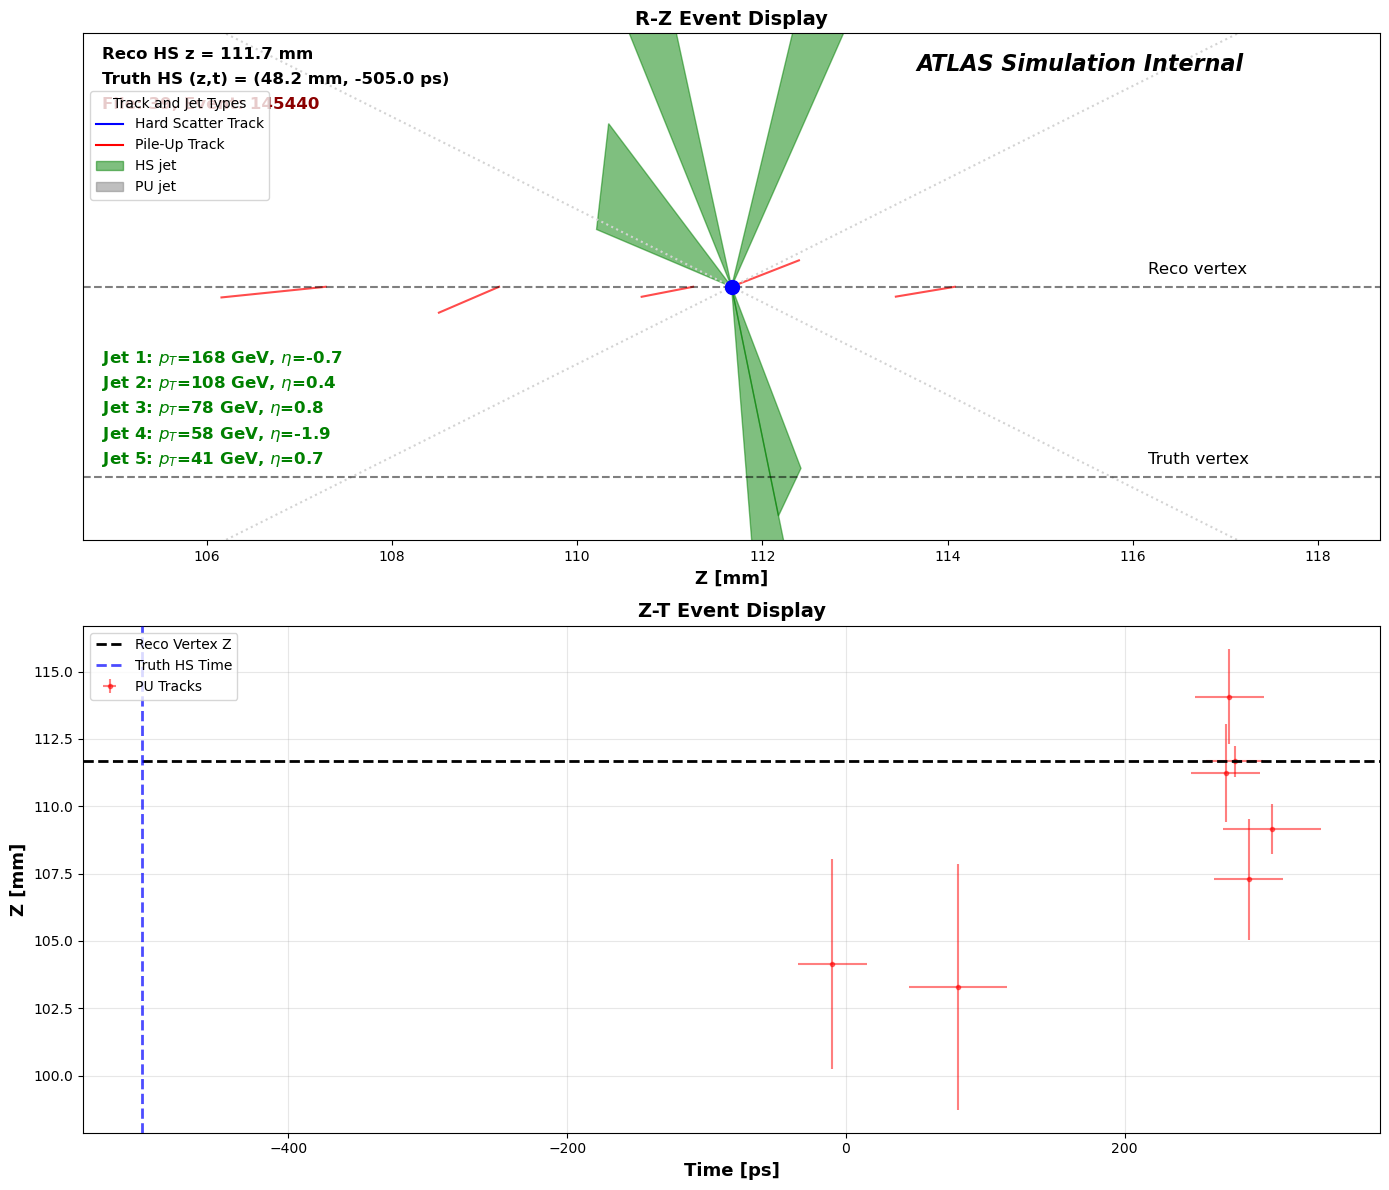

✅ Event display saved to: ./event_displays/event_display_f039_e145440.pdf
📊 Loading event from predictions index 6121
   Event Number: 145440
   File: 39, Index: 1966
   Tracks (HGTD): 7
   Jets: 5


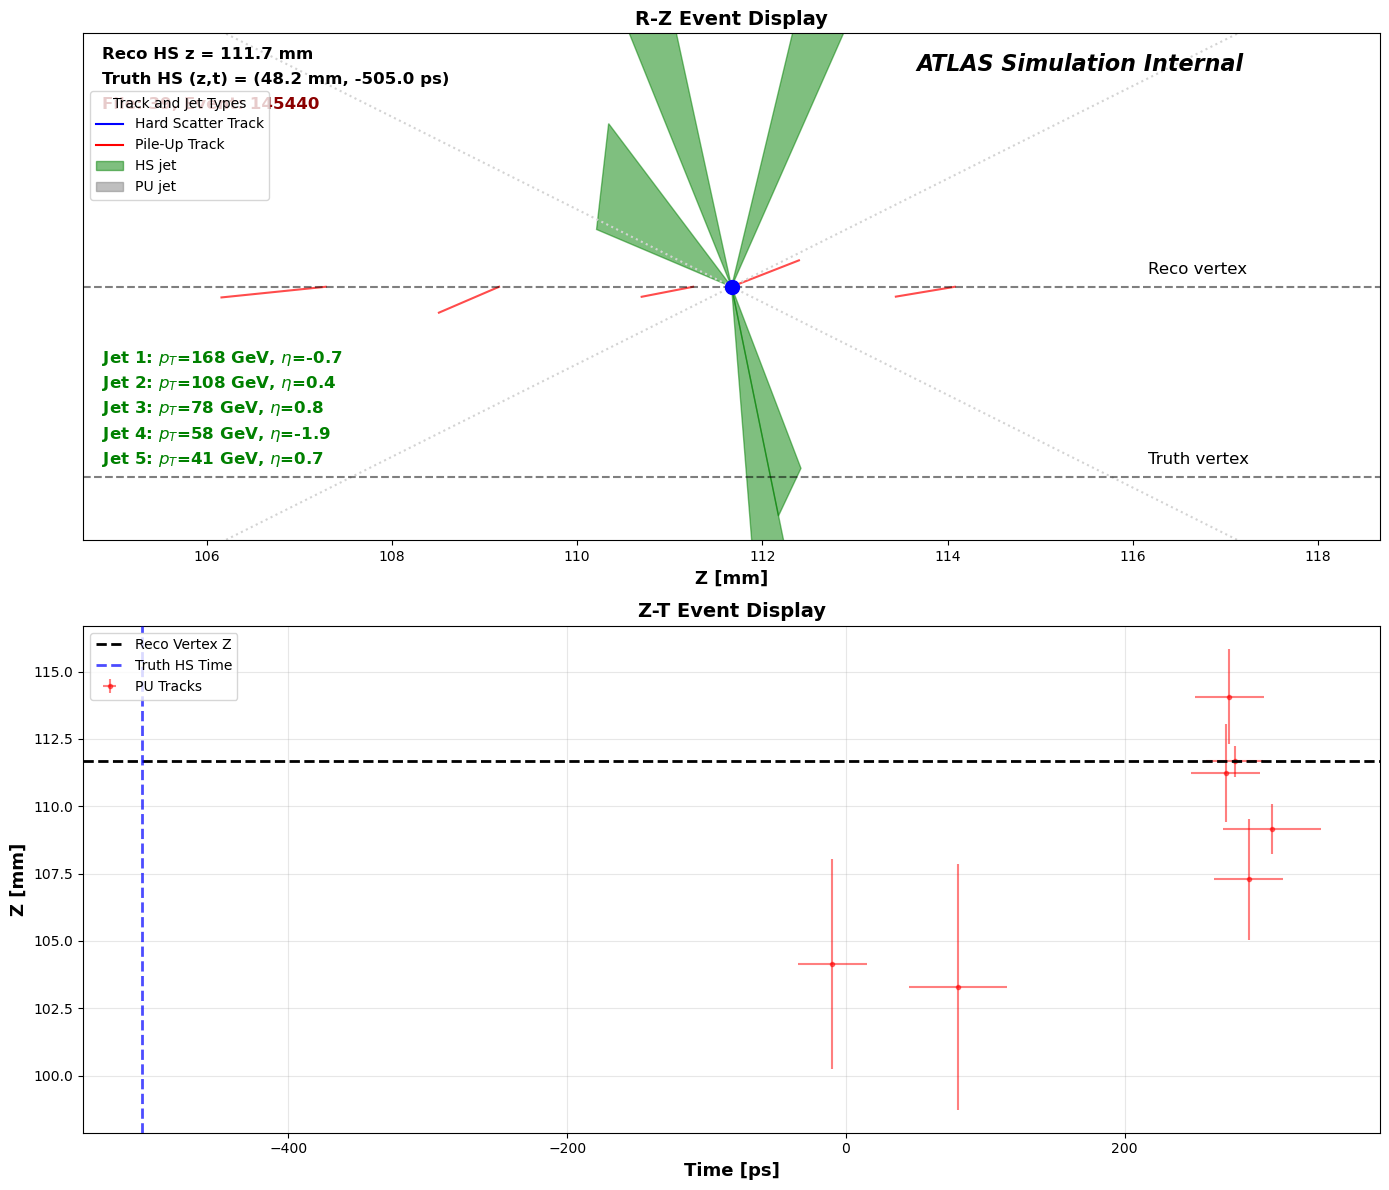

✅ Event display saved to: ./event_displays/event_display_f039_e145440.pdf


In [21]:
# ============================================================================
# Quick Usage
# ============================================================================

# Display a specific event by file and event index
create_event_display(file_num=39, event_number=145440, show_plot=True);

create_event_display(predictions_idx=6121, predictions_data=data_lar_hgtd, show_plot=True);

In [ ]:

# Example 2: Display event with highest Z-score
print("\nExample 2: Display event with highest Z-score")
if has_metadata:
    high_z_idx = df['Z_score'].idxmax()
    create_event_display(predictions_idx=high_z_idx, 
                        predictions_data=data_lar_hgtd,
                        show_plot=True)
else:
    print("⚠️  No metadata available")

# Example 3: Display top 5 events with highest Z-score
print("\nExample 3: Batch display - top 5 highest Z-score events")
if has_metadata:
    batch_event_display(df, column='Z_score', n_events=5, ascending=False)
else:
    print("⚠️  No metadata available")